<a href="https://colab.research.google.com/github/Santibareiro27/Inteligencia-Computacional/blob/santi/RA1_LAB1/Laboratorio_N%C2%B01_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Experiencia 3 - Optimización de mezclas de hormigón para obra civil

##0. Consideraciones y configuracion del entorno

Estas son las consideraciones iniciales que debemos tener en cuenta a la hora de entrenar el modelo y buscar soluciones a nuestra problematica.

Objetivos:
- Reducir costo de mezclas de hormigón
- Cumplir con los requisitos mínimos de MPa.
- Compensar cemento con agregados.

Información previa:
- El cemento tiene una relacion lineal con el MPa
- Los agregados tienen una relacion no lineal con el MPa

Riesgos del *target*:
- Subestimar la resistencia es un costo extra innecesario
- Sobreestimar la resistencia es un error estructural fatal

In [74]:
# @title #####Configuracion del entorno

# Importaciones
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split

# Modulos no instalados
!pip install lazypredict
from lazypredict.Supervised import LazyRegressor

# Reproducibilidad
SEED = 42
np.random.seed(SEED)

print("Entorno configurado.")

Entorno configurado.


##1. Carga y exploracion inicial

###1.1 Carga de datos

In [30]:
# Archivos pueden arrastrarse al área de trabajo o procesarse en local

# Version Online
if not os.path.exists("datos_ccs.zip"):
  !wget https://github.com/AxelSkrauba/applied-ai-engineering/raw/main/datasets/ccs/datos_ccs.zip

In [31]:
if not os.path.exists("datos_ccs.csv"):
    !unzip datos_ccs.zip
df_ccs = pd.read_csv("datos_ccs.csv")

###1.2 Inspeccion inicial y calidad de datos

In [34]:
print(f"Dimensiones: {df_ccs.shape}")
print(f"\nTipos de datos:\n{df_ccs.dtypes}")
print(f"\nFaltantes: {df_ccs.isnull().sum().sum()} (ninguno)")
print(f"\nPrimeras filas:")
df_ccs

Dimensiones: (1030, 9)

Tipos de datos:
cement              float64
slag                float64
flyash              float64
water               float64
superplasticizer    float64
coarseaggregate     float64
fineaggregate       float64
age                   int64
csMPa               float64
dtype: object

Faltantes: 0 (ninguno)

Primeras filas:


,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30
...,...,...,...,...,...,...,...,...,...
1025,276.4,116.0,90.3,179.6,8.9,870.1,768.3,28,44.28
1026,322.2,0.0,115.6,196.0,10.4,817.9,813.4,28,31.18
1027,148.5,139.4,108.6,192.7,6.1,892.4,780.0,28,23.70
1028,159.1,186.7,0.0,175.6,11.3,989.6,788.9,28,32.77


In [35]:
print("Detectando valores negativos:")
negative_values_found = False
for column in df_ccs.columns:
    if (df_ccs[column] < 0).any():
        negative_values_found = True
        print(f"  - La columna '{column}' contiene valores negativos.")
        print(df_ccs[df_ccs[column] < 0][column])

if not negative_values_found:
    print("  - No se encontraron valores negativos en el dataset.")

Detectando valores negativos:
  - No se encontraron valores negativos en el dataset.


##2. Análisis exploratorio orientado al problema

In [44]:
# @title Tabla de media, desviación estándar y coeficiente de variación (CV)
columnas_numericas = df_ccs.select_dtypes(include=['number']).columns

# Calcular la media y la desviaci3n est1ndar para cada columna num1rica
valores_media = df_ccs[columnas_numericas].mean()
valores_desviacion = df_ccs[columnas_numericas].std()

# CV = Desviaci3n Est1ndar / Media
cv = (valores_desviacion / valores_media)

# Crear un DataFrame para mostrar los resultados
medidas_df = pd.DataFrame({
    'Media': valores_media,
    'Desviación Estándar': valores_desviacion,
    'Coeficiente de Variación': cv
})

# Obtener el orden de las columnas basado en CV (excluyendo csMPa)
columnas_ordenadas_cv = cv.drop('csMPa').sort_values(ascending=True).index.tolist()
columns_order = columnas_ordenadas_cv + ['csMPa']

# Transponer y reordenar
medidas_df = medidas_df.T[columns_order]

# Mostrar el DataFrame
display(medidas_df)

,coarseaggregate,fineaggregate,water,cement,superplasticizer,slag,flyash,age,csMPa
Media,972.918932,773.580485,181.567282,281.167864,6.204660,73.895825,54.188350,45.662136,35.817961
Desviación Estándar,77.753954,80.175980,21.354219,104.506364,5.973841,86.279342,63.997004,63.169912,16.705742
Coeficiente de Variación,0.079918,0.103643,0.117610,0.371687,0.962799,1.167581,1.181010,1.383420,0.466407


- Poca variacion en el agua y agregados (base constante).
- Variacion moderada en cemento.
- Gran variacion en aditivos y edad.

In [55]:
# @title Tabla de media, mediana, Dif. Absoluta, Dif. Porcentual de cada variable.
# Calcular la media y la mediana para cada columna numérica
valores_mediana = df_ccs[columnas_numericas].median()

# Calcular la diferencia absoluta entre la media y la mediana
diferencia = (valores_media - valores_mediana).abs()

# Calcular la diferencia porcentual
diferencia_porcentual = (diferencia / valores_media) * 100

# Crear un DataFrame para mostrar los resultados
diferencia_df = pd.DataFrame({
    'Media': valores_media,
    'Mediana': valores_mediana,
    'Diferencia Absoluta (Media - Mediana)': diferencia,
    'Diferencia Porcentual (%)': diferencia_porcentual
})

columnas_ordenadas_dp = diferencia_porcentual.drop('csMPa').sort_values(ascending=True).index.tolist()
columns_order = columnas_ordenadas_dp + ['csMPa']

diferencia_df = diferencia_df.T[columns_order]

display(diferencia_df)

,coarseaggregate,fineaggregate,water,cement,superplasticizer,age,slag,flyash,csMPa
Media,972.918932,773.580485,181.567282,281.167864,6.204660,45.662136,73.895825,54.18835,35.817961
Mediana,968.000000,779.500000,185.000000,272.900000,6.400000,28.000000,22.000000,0.00000,34.445000
Diferencia Absoluta (Media - Mediana),4.918932,5.919515,3.432718,8.267864,0.195340,17.662136,51.895825,54.18835,1.372961
Diferencia Porcentual (%),0.505585,0.765210,1.890604,2.940544,3.148276,38.680048,70.228359,100.00000,3.833164


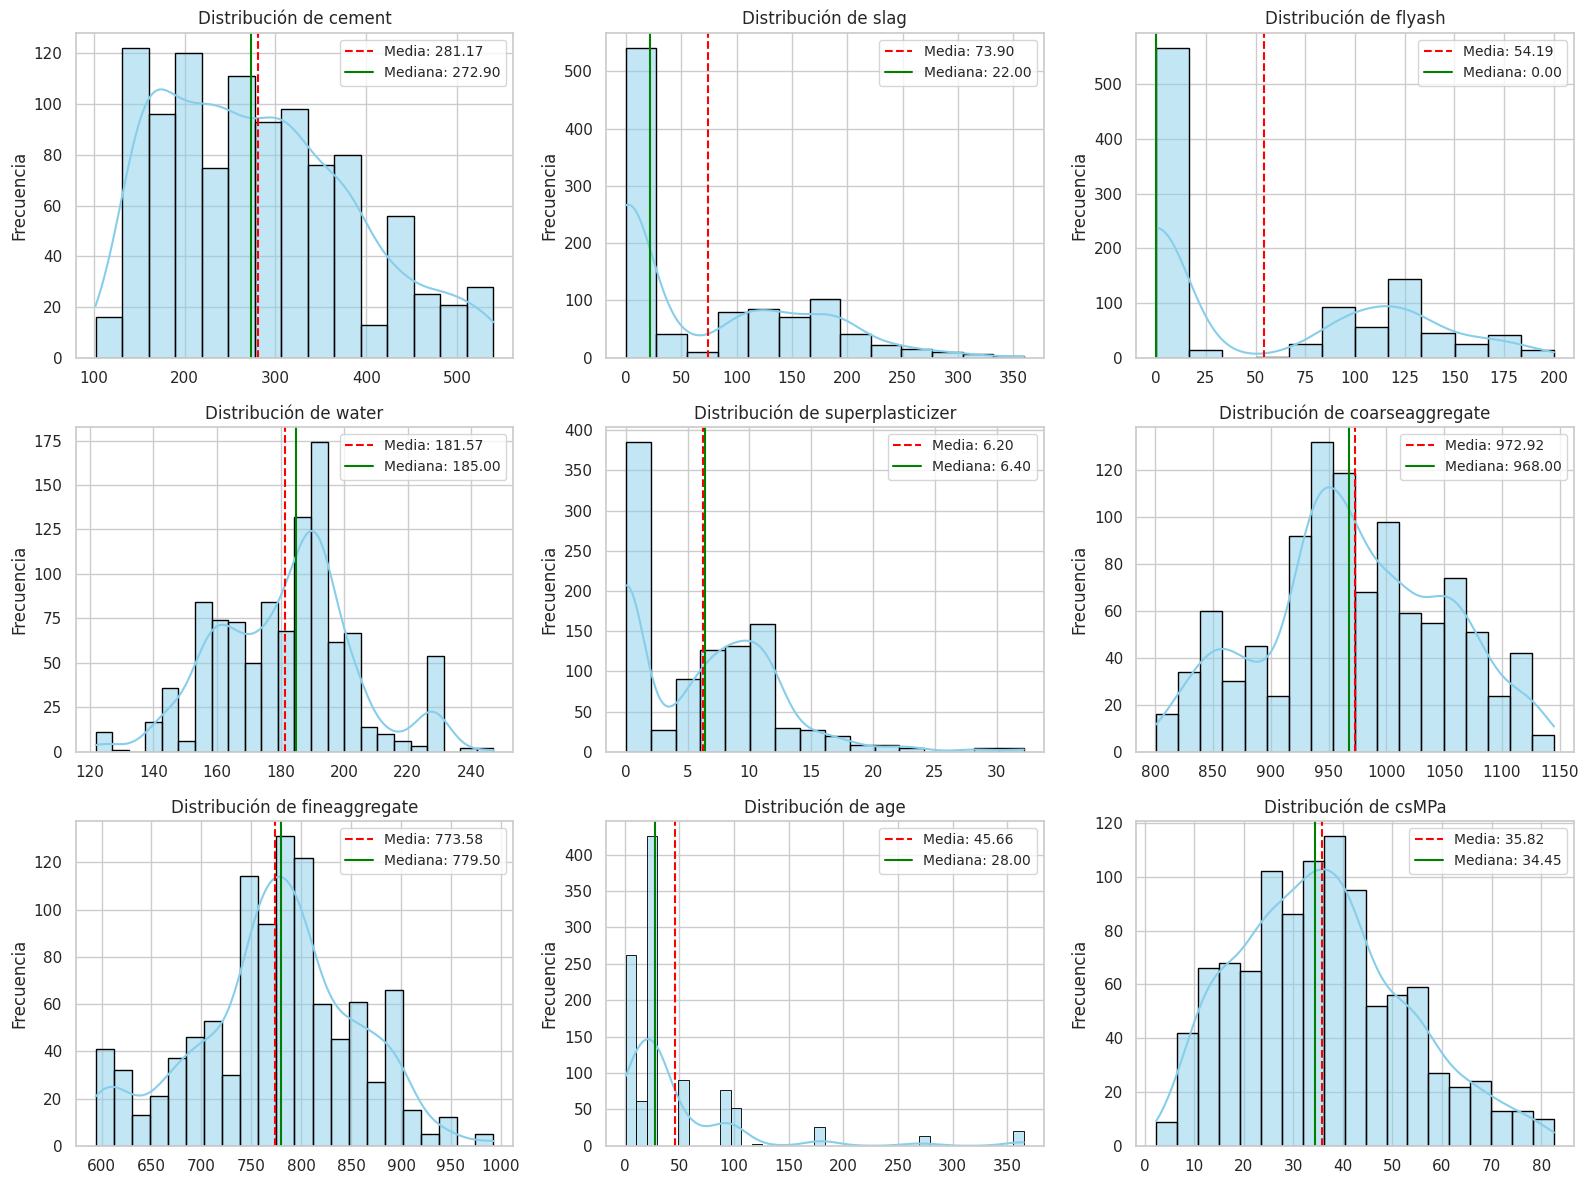

In [56]:
# @title Histogramas de distribución para todas las variables
# Configurar el estilo de Seaborn
sns.set_theme(style="whitegrid")

# Definir el número de filas y columnas para la cuadrícula
n_cols = 3
n_rows = (len(df_ccs.columns) + n_cols - 1) // n_cols

# Crear la figura
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

# Graficar cada variable
for i, col in enumerate(df_ccs.columns):
    sns.histplot(df_ccs[col], kde=True, ax=axes[i], color='skyblue', edgecolor='black')

    # Calcular media y mediana
    mean_val = df_ccs[col].mean()
    median_val = df_ccs[col].median()

    # Agregar líneas de referencia
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Media: {mean_val:.2f}')
    axes[i].axvline(median_val, color='green', linestyle='-', label=f'Mediana: {median_val:.2f}')

    axes[i].set_title(f'Distribución de {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')
    axes[i].legend(fontsize='small')

# Eliminar ejes vacíos si los hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- Distribucion simetrica en `coarseaggregate`, `fineaggregate	` y `water`.
- Distribucion ligeramente sesgada (hacia la derecha) en `cement` y `csMPa`.
- Distribucion altamente sesgada (hacia la derecha) en `age`.
- Distribucion bimodal en `slag`, `flyash` y `superplasticizer`.



Distribuciones

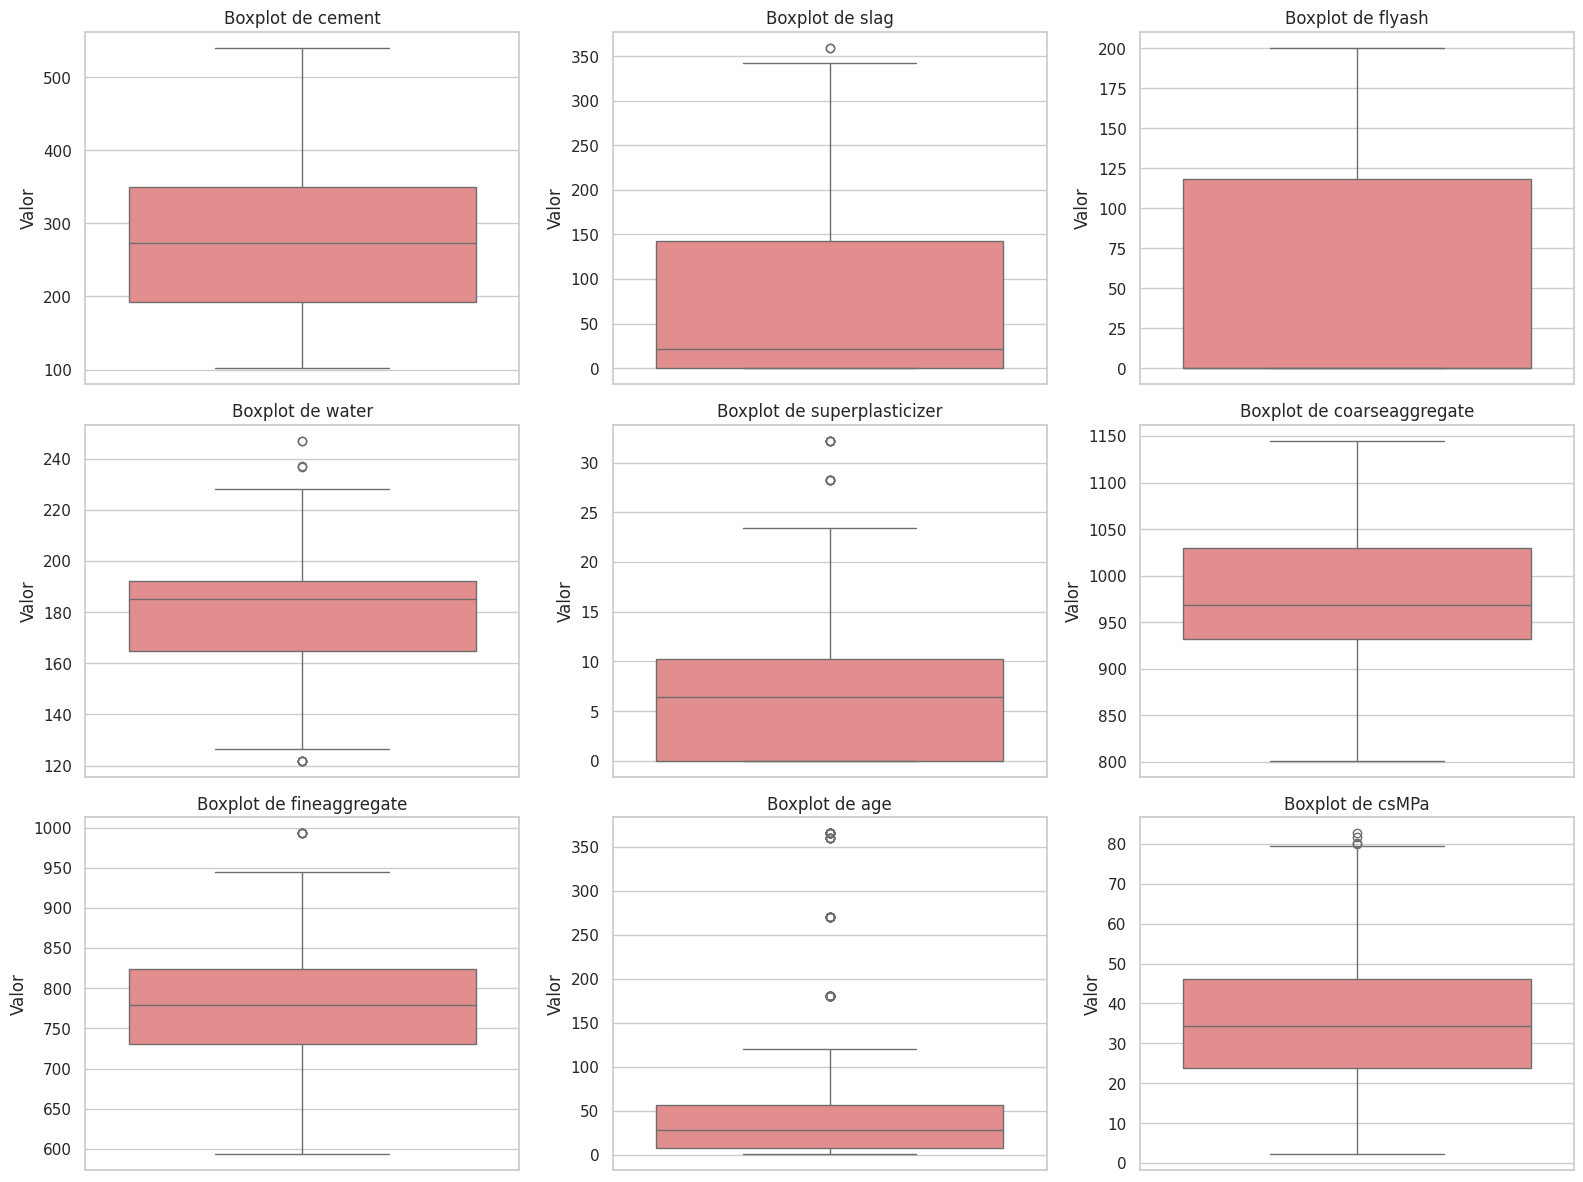

In [57]:
# @title Diagramas de caja (Boxplots) para todas las variables
# Configurar el estilo de Seaborn
sns.set_theme(style="whitegrid")

# Definir el número de filas y columnas para la cuadrícula
n_cols = 3
n_rows = (len(df_ccs.columns) + n_cols - 1) // n_cols

# Crear la figura
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

# Graficar cada variable
for i, col in enumerate(df_ccs.columns):
    sns.boxplot(y=df_ccs[col], ax=axes[i], color='lightcoral')
    axes[i].set_title(f'Boxplot de {col}', fontsize=12)
    axes[i].set_ylabel('Valor')
    axes[i].set_xlabel('')

# Eliminar ejes vacíos si los hay
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [68]:
# Calcular IQR para csMPa
Q1 = df_ccs['csMPa'].quantile(0.25)
Q3 = df_ccs['csMPa'].quantile(0.75)
IQR = Q3 - Q1
inferior = Q1 - 1.5 * IQR
superior = Q3 + 1.5 * IQR

# Filtrar outliers
outliers_csMPa = df_ccs[(df_ccs['csMPa'] < inferior) | (df_ccs['csMPa'] > superior)]

print(f"Límite inferior: {inferior:.2f}")
print(f"Límite superior: {superior:.2f}")
print(f"Total de outliers detectados: {len(outliers_csMPa)}")

outliers_csMPa.sort_values(by='csMPa', ascending=False)

Límite inferior: -9.93
Límite superior: 79.77
Total de outliers detectados: 4


,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
181,389.9,189.0,0.0,145.9,22.0,944.7,755.8,91,82.60
381,315.0,137.0,0.0,145.0,5.9,1130.0,745.0,28,81.75
153,323.7,282.8,0.0,183.8,10.3,942.7,659.9,56,80.20
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99


Los valores tienen sentido aparente

In [77]:
# @title Prototipado Rápido

# 1. Preparación de datos para entrenamiento
X = df_ccs.drop(columns=['csMPa'])
y = df_ccs['csMPa']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

# 2. Inicializar y entrenar LazyRegressor
reg = LazyRegressor(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = reg.fit(X_train, X_test, y_train, y_test)

# 3. Mostrar resultados (Todos los modelos)
print("Comparativa completa de modelos evaluados:")
pd.set_option('display.max_rows', None)  # Asegurar que se muestren todos en el notebook
display(models)

Comparativa completa de modelos evaluados:


,Adjusted R-Squared,R-Squared,RMSE,Time Taken
Model,,,,
XGBRegressor,0.914312,0.917656,4.606305,0.247861
HistGradientBoostingRegressor,0.913975,0.917332,4.615362,0.209071
LGBMRegressor,0.909000,0.912551,4.746958,0.077961
ExtraTreesRegressor,0.888543,0.892893,5.253479,0.304786
RandomForestRegressor,0.879465,0.884169,5.463242,0.564936
GradientBoostingRegressor,0.878133,0.882889,5.493350,0.258148
BaggingRegressor,0.854371,0.860054,6.005076,0.077433
DecisionTreeRegressor,0.828040,0.834750,6.525414,0.016315
ExtraTreeRegressor,0.799692,0.807509,7.042768,0.012953


Se puede observar un claro exito en los modelos **no lineales** como arboles de decision y vectores gradientes.

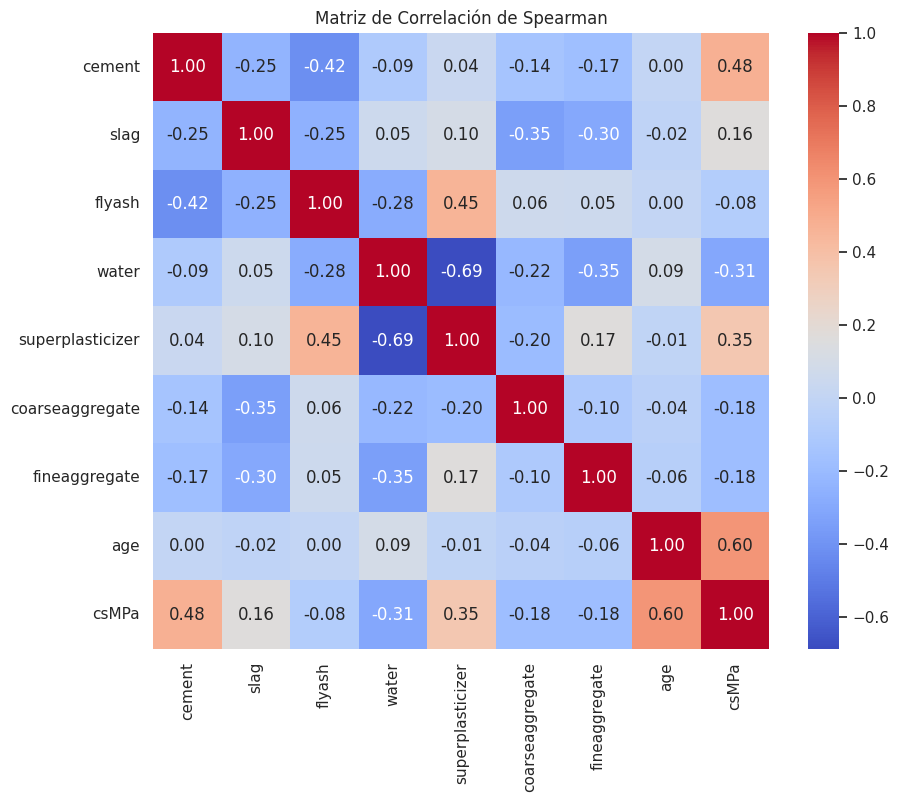

In [69]:
# @title Matriz de Correlación de Spearman
plt.figure(figsize=(10, 8))
corr_spearman = df_ccs.corr(method='spearman')
sns.heatmap(corr_spearman, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Matriz de Correlación de Spearman')
plt.show()

Relaciones lineales
- El csMPa tiene buenas correlaciones con el cemento, el agua y la edad, lo cual tiene sentido segun la informacion recopilada.
- El superplastificante parece tener mucha correlacion con el agua (material suplementario del agua), ademas de influir mucho en nuestro target.
- La escoria (*slag*) y las cenizas volantes (*fly ash*) tienen correlacion con el cemento (materiales suplementarios del cemento).

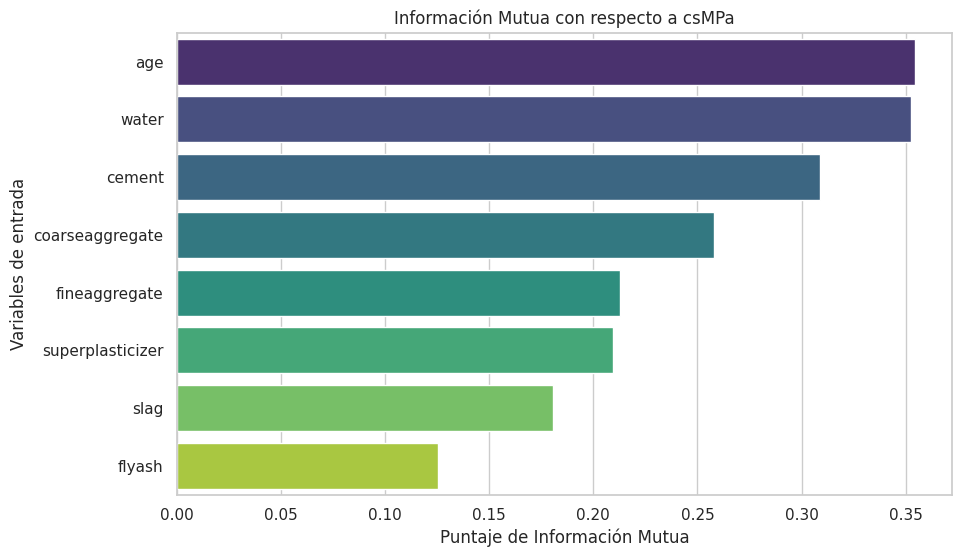

In [72]:
from sklearn.feature_selection import mutual_info_regression

# Preparar datos
X = df_ccs.drop('csMPa', axis=1)
y = df_ccs['csMPa']

# Calcular información mutua
mi_scores = mutual_info_regression(X, y, random_state=SEED)
mi_series = pd.Series(mi_scores, name="Información Mutua", index=X.columns)
mi_series = mi_series.sort_values(ascending=False)

# Graficar
plt.figure(figsize=(10, 6))
sns.barplot(x=mi_series.values, y=mi_series.index, hue=mi_series.index, palette='viridis', legend=False)
plt.title('Información Mutua con respecto a csMPa')
plt.xlabel('Puntaje de Información Mutua')
plt.ylabel('Variables de entrada')
plt.show()

Informacion mutua
- Otra vez los mas influyentes son la edad, el cemento y el agua.
- El superplastificante bajo un poco, pero se mantiene en la ecuacion.

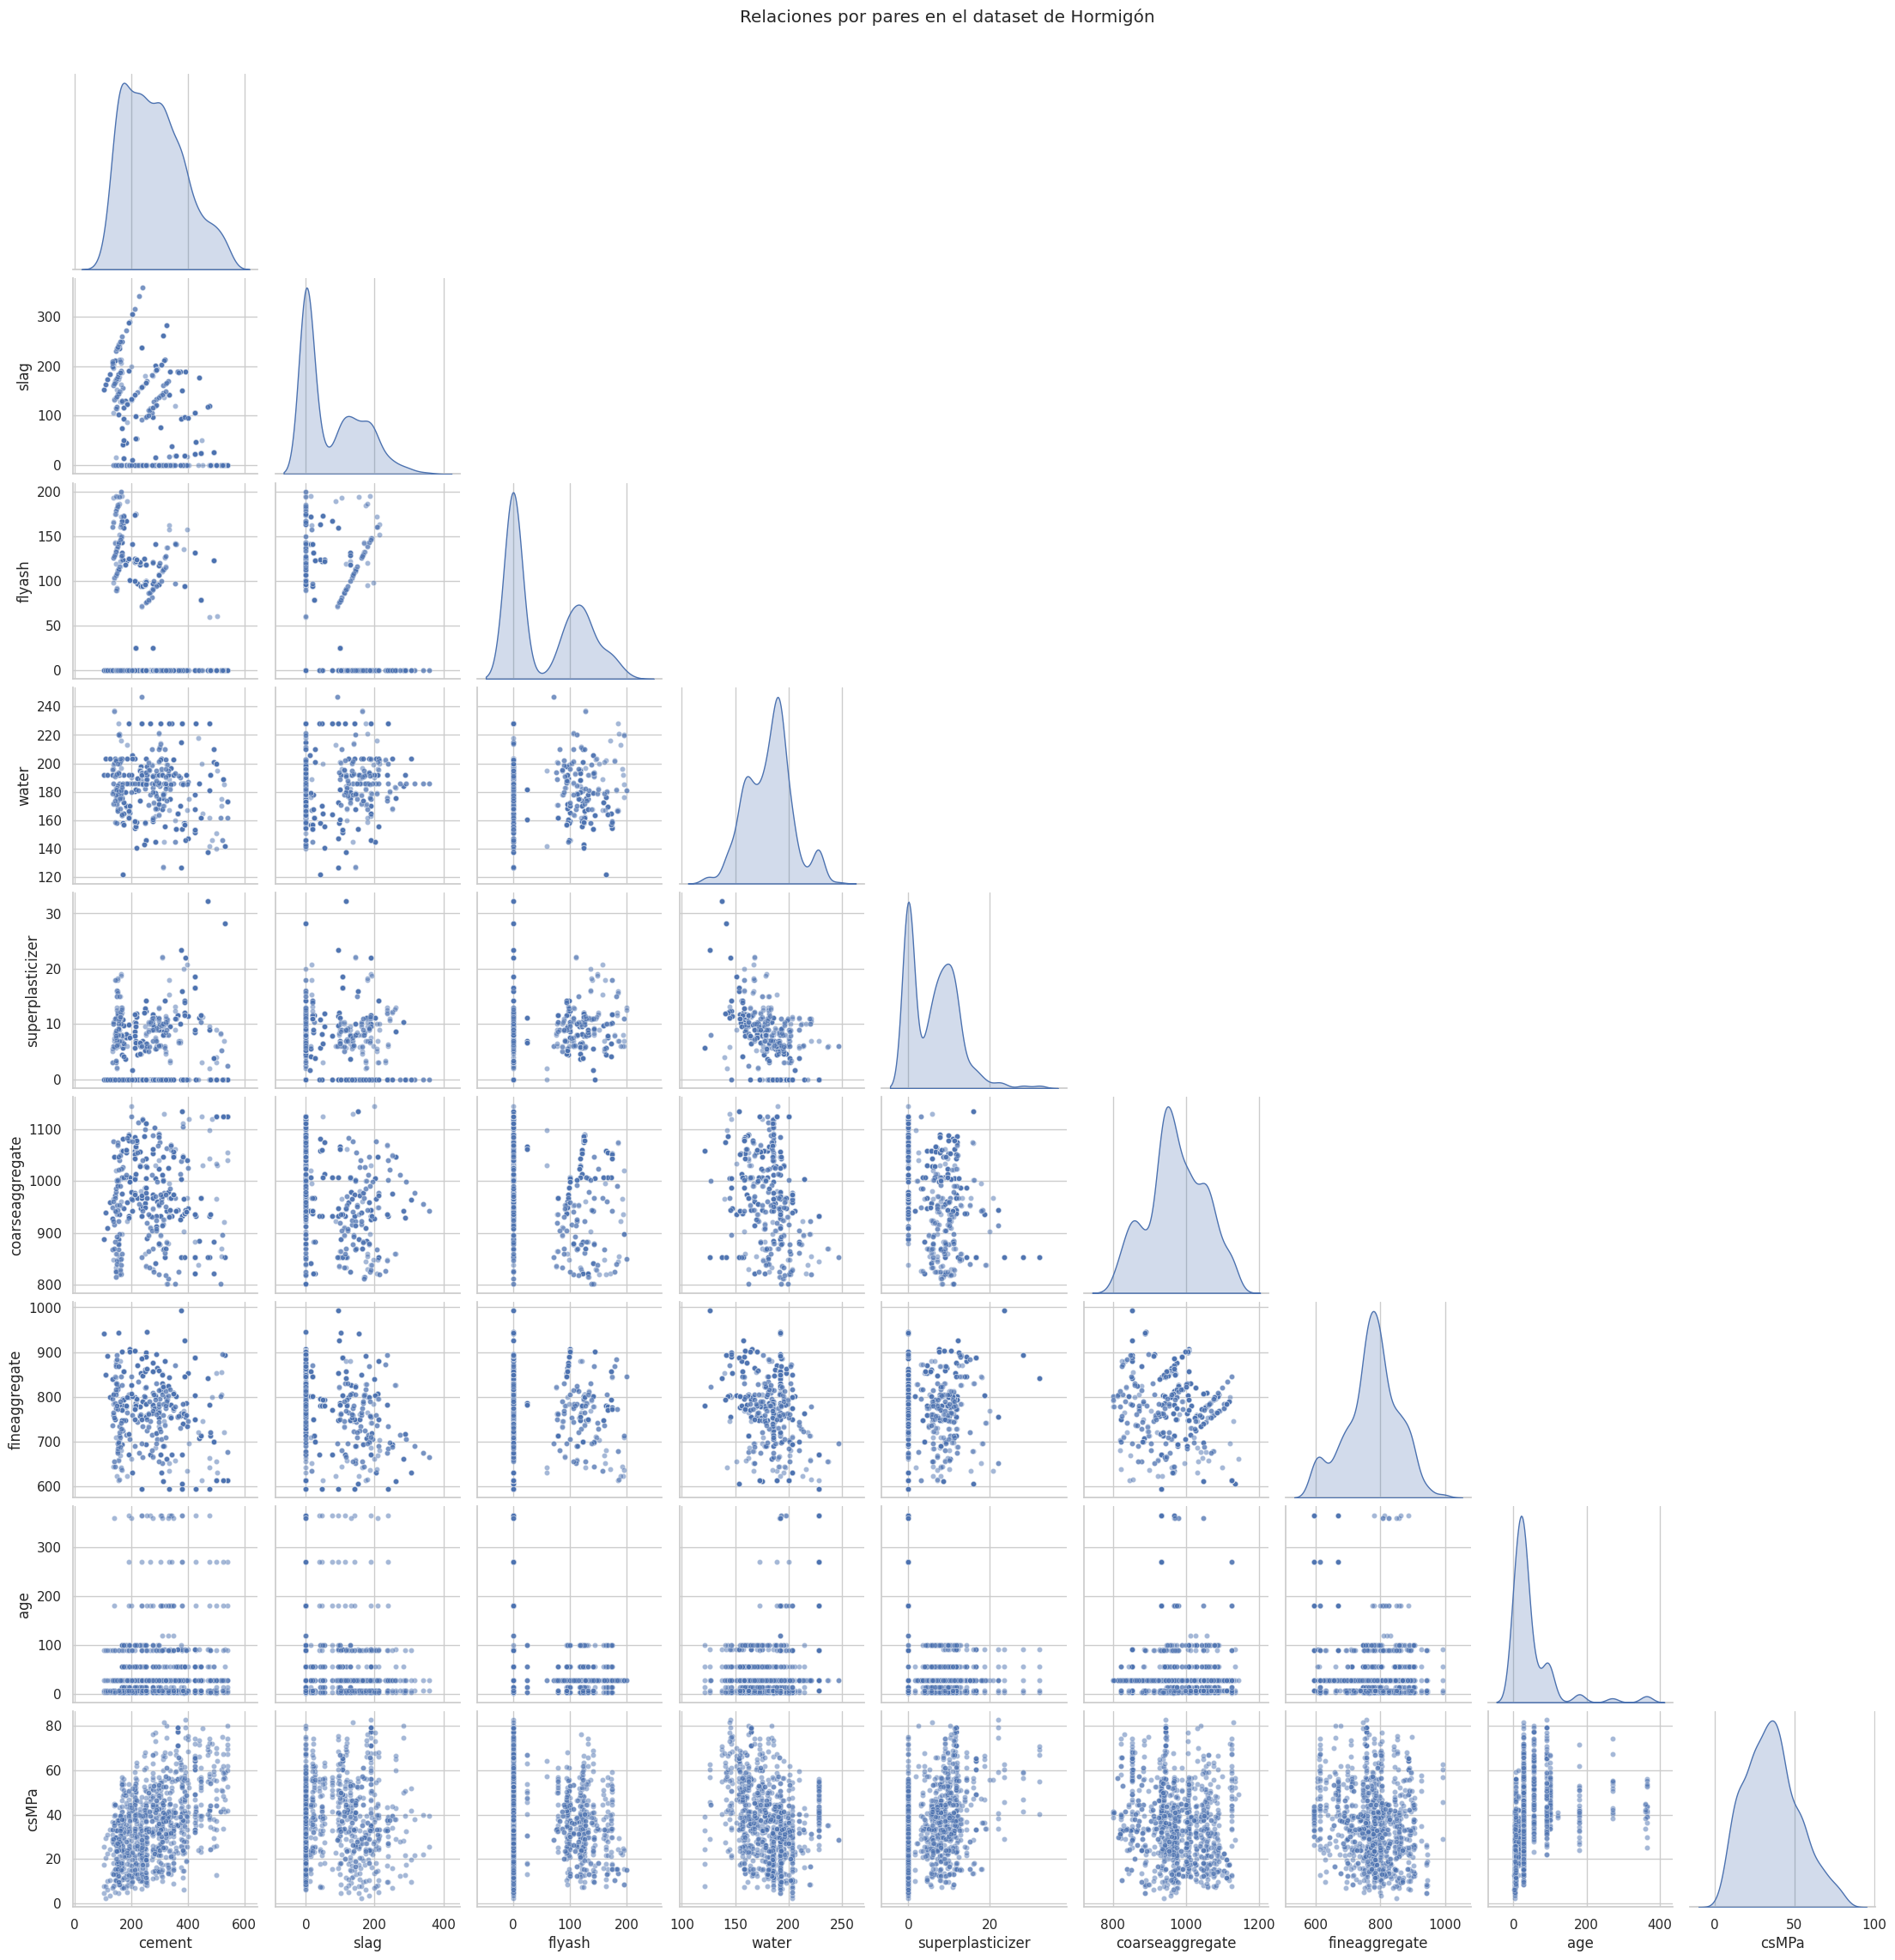

In [78]:
# @title Pairplot de variables
sns.pairplot(df_ccs, diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20}, corner=True)
plt.suptitle('Relaciones por pares en el dataset de Hormigón', y=1.02)
plt.show()